# Tools - 工具
工具扩展了智能体的能力，允许它们获取实时数据、执行代码、查询外部数据库以及在世界中采取行动。

在底层，工具就是是具有 **明确定义** 的输入和输出的 **可调用函数** ,
这些输入和输出会被传递给模型。模型根据对话上下文决定何时调用工具，以及提供什么输入参数



## Create Tools

### 基本的Tools创建
创建工具最简单的方法是使用 `@tool` 装饰器。默认情况下，函数的文档字符串（doc-string）成为工具的描述，帮助模型理解何时使用它，会加载到context上下文中。



In [2]:
from langchain.tools import tool

@tool
def search_db(query: str, limit: int = 10) -> str:
    """Search the customer database for records matching the query.

    Args:
        query (str): Search terms to look for
        limit (int, optional): Maximum number of results to return. Defaults to 10
    """
    return f"Found {limit} results for '{query}'"


【⚠️注意】

定义Tools的时候要进行 **类型提示** 

在定义工具的时候还可以在装饰器里面传入 name 和 description

In [3]:
@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))
#? @tool 的第一个参数是名字，描述传入
# 这里面传入的


## 高级的工具定义

通过类型提示如果遇到复杂的输入格式可能不太行，比如说要指定输入的字面量等等，这是有就要定义复杂的输入格式 schema

有两种实现方式一种是Pydantic的BaseModel，一种是json格式定义

In [ ]:
from pydantic import BaseModel, Field
# BaseModel 是用来继承的
# Field 是定义默认值和描述的
from typing import Literal
# Literal 用于指定字面量

class WeatherInput(BaseModel):
    """Input for weather queries."""
    location: str = Field(description="City name or coordinates")
    units: Literal["celsius", "fahrenheit"] = Field(
        default="celsius",
        description="Temperature unit preference"
    )
    include_forecast: bool = Field(
        default=False,
        description="Include 5-day forecast"
    )
    
#? tool(args_schema = ) 
@tool(args_schema=WeatherInput)
def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
    """Get current weather and optional forecast."""
    temp = 22 if units == "celsius" else 72
    result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
    if include_forecast:
        result += "\nNext 5 days: Sunny"
    return result

#! args_schema 的类型
# (type) ArgsSchema = type[BaseModel] | dict[str, Any]
# dict也就是json格式

In [ ]:
 #? 使用json格式

weather_schema = {
    "type": "object",
    "properties": {
        "location": {"type": "string"},
        "units": {"type": "string"},
        "include_forecast": {"type": "boolean"}
    },
    "required": ["location", "units", "include_forecast"]
}

#! 使用json格式的话就不能指定units的字面量，只能指定默认值

print(type(weather_schema))

@tool(args_schema=weather_schema)
def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
    """Get current weather and optional forecast."""
    temp = 22 if units == "celsius" else 72
    result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
    if include_forecast:
        result += "\nNext 5 days: Sunny"
    return result

<class 'dict'>


tool装饰器的args：

以下参数名称是保留的，不能用作工具参数。使用这些名称会导致运行时错误

- config：保留用于在内部将 RunnableConfig 传递给工具
- runtime：保留用于 ToolRuntime 参数（访问状态、上下文、存储）

如果要访问运行时信息，请使用 ToolRuntime 参数，而不是自行命名参数 config 或 runtime

## Access Context 访问上下文

工具能访问运行时的信息，比如说对话历史、用户数据和持久化记忆，Tools可以通过 `ToolRuntime` 访问运行时信息，这是一个类，传入Tools中，然后再Tools中就可以去访问这个类的属性来达到访问上下文的功能。

在工具中访问上下文，通过传入一个参数runtime: ToolRuntime 来在代码中访问，模型对这个是**不可见的**，即模型在调用工具时看不到这个参数，但工具内部的代码可以使用它来获取对话历史或其他状态字段


ToolRuntime的参数：


| 组件 | 描述 | 应用场景 |
| --- | --- | --- |
| State 状态 | 短期记忆 - 当前对话中存在的可变数据（消息、计数器、自定义字段） | 访问对话历史，跟踪工具调用次数 |
| Context 上下文 | 在调用时传递的不可变配置（用户 ID、会话信息） | 根据用户身份个性化回复 |
| Store 存储 | 长期记忆 - 跨对话持续存在的持久数据 | 保存用户偏好，维护知识库 |
| Stream Writer 流写入器 | 在工具执行期间实时发出更新 | 显示长时间运行操作的进度 |
| Config 配置 | RunnableConfig 用于执行 | 访问回调、标签和元数据 |
| Tool Call ID 工具调用 ID | 当前工具调用的唯一标识符 | 关联日志和模型调用的工具调用 |

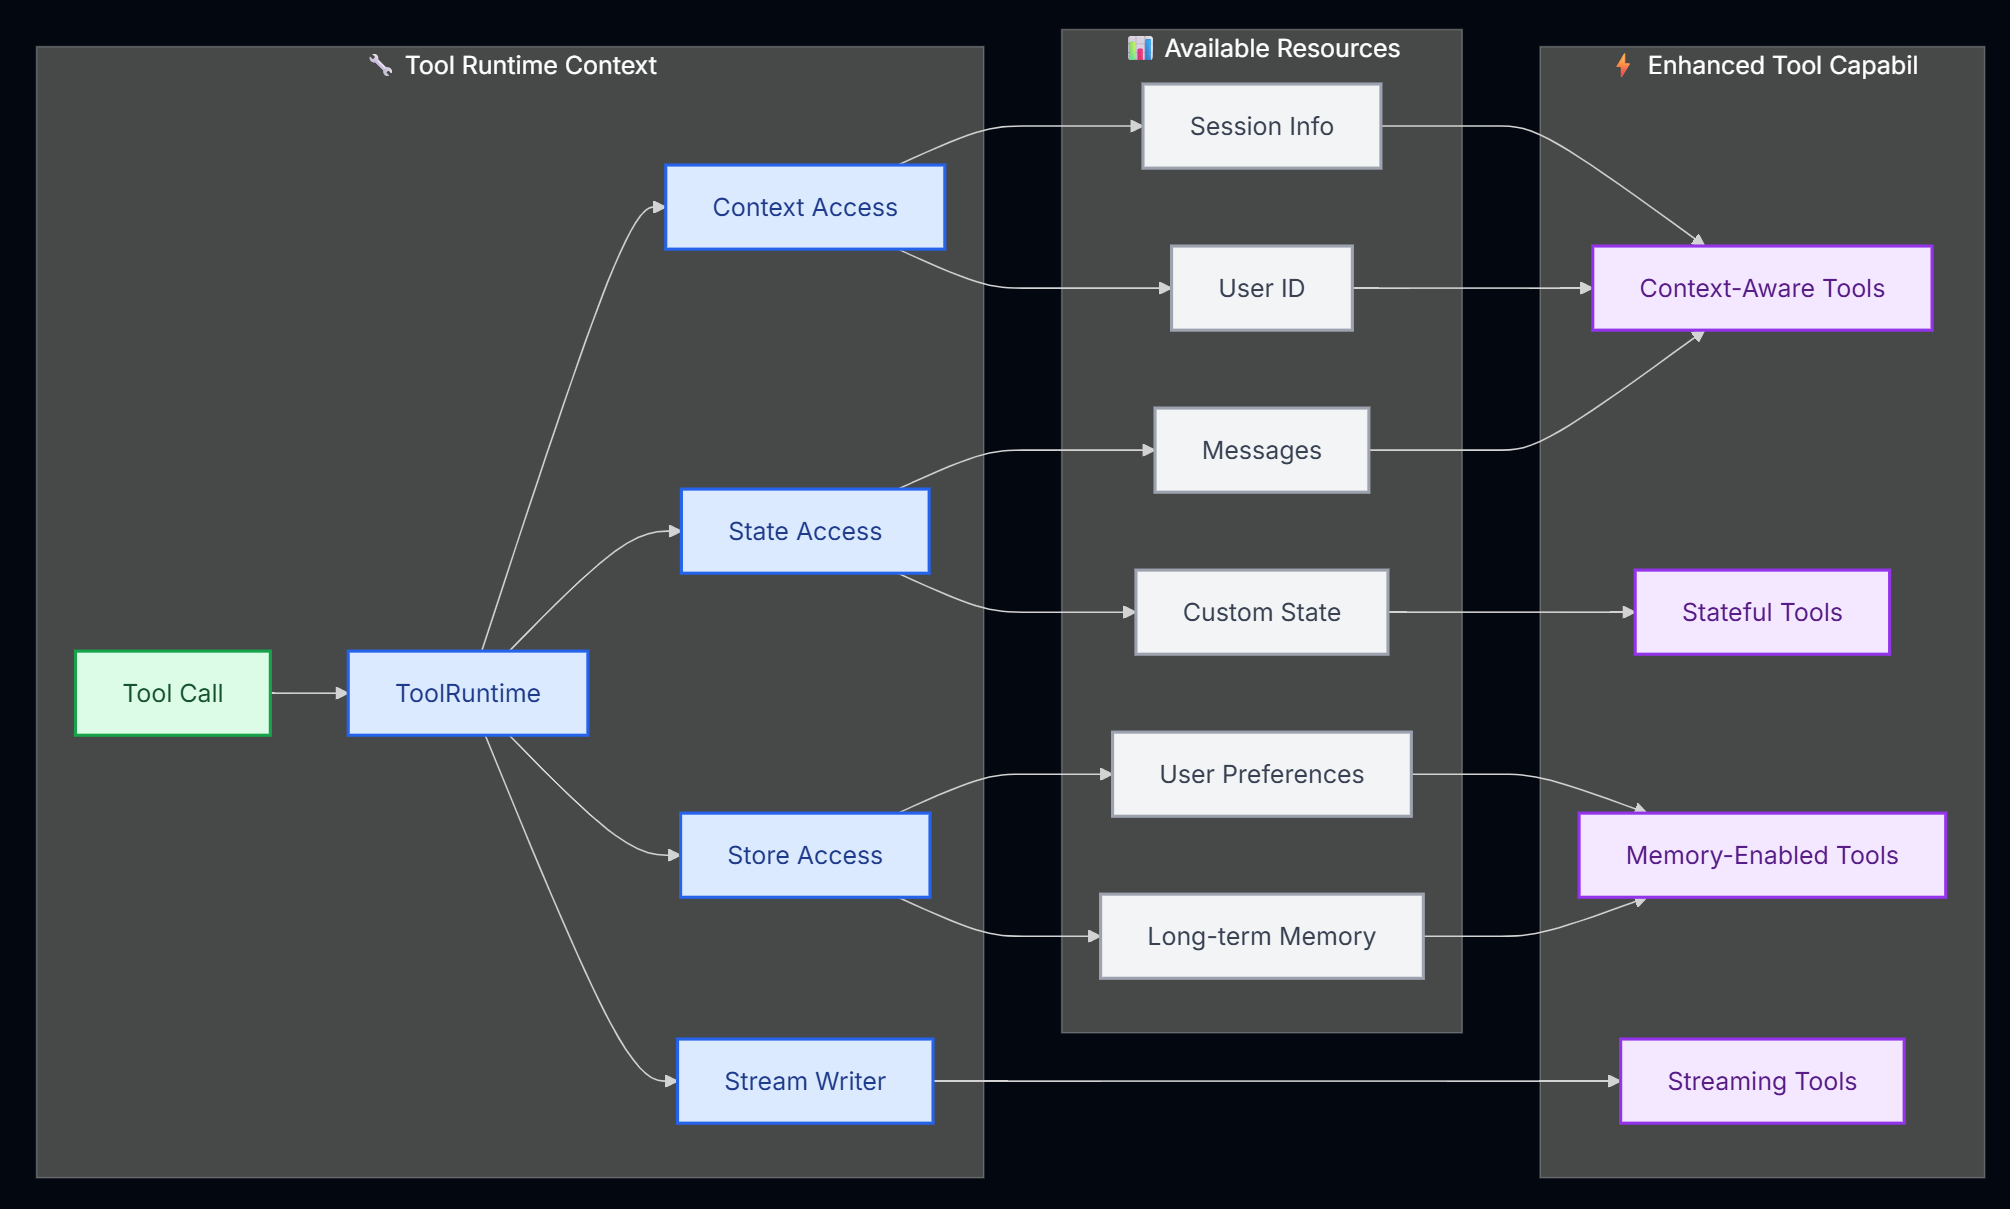


### 短期记忆（state）--状态

state代表了存在对话期间的短期记忆，它包括消息历史记录以及在图状态定义的任何自定义字段

> 在自定义的工具签名中添加 runtime: ToolRuntime 以访问状态，此参数会自动注入并且对模型隐藏 - 不会出现在工具的架构中


#### 通过`runtime.state`来访问state

In [1]:
from langchain.tools import tool, ToolRuntime
from langchain.messages import HumanMessage
from langchain.agents import create_agent


@tool
def get_last_user_message(runtime: ToolRuntime) -> str:
    """Get the most recent message from the user."""
    messages = runtime.state["messages"] # 获取完整的消息列表

    # Find the last human message
    for message in reversed(messages):
        if isinstance(message, HumanMessage): # 早到最后一条
            return message.content
        # isinstance

    return "No user messages found"

# Access custom state fields
@tool
def get_user_preference(
    pref_name: str,
    runtime: ToolRuntime
) -> str:
    """Get a user preference value."""
    preferences = runtime.state.get("user_preferences", {})
    return preferences.get(pref_name, "Not set")

#### update state 更新状态

使用 `Command` 更新Agent的状态，一般用工具来更新自定义状态字段

In [ ]:
from langgraph.types import Command # langgraph.types
from langchain.tools import tool

@tool
def set_user_name(new_name: str) -> Command:
    """Set the user's name in the conversation state."""
    return Command(update={"user_name": new_name}) # update传入一个dict

### Context 上下文
上下文提供了**不可更改**的配置数据，在调用（invoke）时传递。用于**用户 ID**、**会话详细信息**或**对话期间不应更改的特定于应用程序的设置**

一旦设置，这些数据在单次对话运行期间保持不变

通过`runtime.context`来访问上下文


In [7]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain.tools import tool, ToolRuntime

# 模拟数据库
USER_DATABASE = {
    "user123": {
        "name": "Alice Johnson",
        "account_type": "Premium",
        "balance": 5000,
        "email": "alice@example.com"
    },
    "user456": {
        "name": "Bob Smith",
        "account_type": "Standard",
        "balance": 1200,
        "email": "bob@example.com"
    }
}

# 自定义一个用户context的schema
@dataclass
class UserContext:
    user_id: str
    
@tool
def get_account_info(runtime: ToolRuntime[UserContext]) -> str:
    """获取当前User的账户信息"""
    # 为什么要传入UserContext这个泛型，可以让编辑器知道context是什么类
    user_id: str = runtime.context.user_id 
    
    if user_id in USER_DATABASE:
        user = USER_DATABASE[user_id]
        return f"Account holder: {user['name']}\nType: {user['account_type']}\nBalance: ${user['balance']}"
    return "找不到User"

import os 
model = ChatOpenAI(
    model="Qwen/Qwen2.5-7B-Instruct",
    base_url="https://api.siliconflow.cn/v1",
    api_key=os.environ.get("SILICONFLOW_API_KEY"),
    temperature=0.2,
)

agent = create_agent(
    model,
    tools=[get_account_info],
    context_schema=UserContext,
    system_prompt="你是个财金助手"
)

res: dict = agent.invoke( # invoke期间不会改变context
    {"messages": [{"role": "user", 
                   "content": "What's my current balance? and my name?"
                   }]},
    context=UserContext(user_id="user123") # 指定一个schema
)
print(res['messages'][-1].content)

Your current balance is $5000 and your name is Alice Johnson.


【思考🤔】：如果我想定义多个Context Schema怎么办

我觉得可以定义一个 BaseContext 作为基类，基类中包含所有可能使用到的字段，然后一些可选的就 | None = None 默认值设置为None，然后后续需要定义新的字段就继承基类



### Long-term memory (Store)  长期记忆 (存储)

`BaseStore` 提供持久化存储，可以在对话之间持续存在，“跨对话”的记忆。存储在其中的数据在未来的会话中仍然可用

通过 runtime.store 访问存储。存储使用**命名空间/键模式**来组织数据

> 在生产环境中部署时，请使用持久化存储实现，例如 PostgresStore ，而不是 InMemoryStore 



【什么是命名空间、键、值】

| 概念 | 文件系统类比 | 例子 |
| --- | --- | --- |
| 命名空间 (namespace)​ | 文件夹/目录 | ("users",) 表示"用户"这个文件夹 |
| 键 (key)​ | 文件名 | "user123" 表示具体的某个文件 |
| 值 (value)​ | 文件内容 | {"name": "Alice", "age": 25} |

In [ ]:
from typing import Any
from langgraph.store.memory import InMemoryStore
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime
from langchain_openai import ChatOpenAI
import os

# ============ 第一步：定义工具 ============

# 读取数据
@tool
def get_user_info(user_id: str, runtime: ToolRuntime) -> str:
    """根据用户ID查询用户信息"""
    store = runtime.store
    
    # 使用 get 方法读取，参数为 (命名空间元组, 键)
    user_info = store.get(("users",), user_id)
    
    if user_info is None:
        return f"未找到用户 ID: {user_id}"
    
    # user_info.value 包含实际存储的数据
    return str(user_info.value)

# 写入数据
@tool
def save_user_info(user_id: str, user_info: dict[str, Any], runtime: ToolRuntime) -> str:
    """保存用户信息"""
    store = runtime.store
    
    # 使用 put 方法写入
    # 参数: (命名空间元组, 键, 要存储的值)
    store.put(("users",), user_id, user_info)
    # namespace: tuple[str, ...]
    
    return f"成功保存用户 {user_id} 的信息"

# 删除数据
@tool
def delete_user_info(user_id: str, runtime: ToolRuntime) -> str:
    """删除用户信息"""
    store = runtime.store
    store.delete(("users",), user_id)
    return f"已删除用户 {user_id}"

# 搜索数据
@tool
def search_all_users(runtime: ToolRuntime) -> str:
    """列出所有用户"""
    store = runtime.store

    # search() 返回 List[Item]，Item 包含 value, key, namespace 等属性
    users = store.search(("users",))
    # 第一个参数是 namespace_prefix: tuple[str, ...]
    # 查询的命名空间的前缀
    # 也可以指定filter过滤，只查询特定的字段
    
    if not users:
        return "暂无用户数据"

    # 提取每个用户的实际数据 (item.value 包含存储的值)
    user_list = [str(item.value) for item in users]
    return "\n".join(user_list)


# ============ 第二步：创建 Store 实例 ============

# 开发测试用 InMemoryStore（数据存储在内存中，重启后丢失）
store = InMemoryStore()

# ============ 第三步：创建 Agent ============

model = ChatOpenAI(
    model="deepseek-ai/DeepSeek-V3.2",
    #! 这里要注意，模型的Tools能力也挂钩
    base_url="https://api.siliconflow.cn/v1",
    api_key=os.environ.get("SILICONFLOW_API_KEY"),
    temperature=0.2,
)

agent = create_agent(
    model,
    tools=[get_user_info, save_user_info, delete_user_info, search_all_users],
    store=store,  # 绑定 store 到 agent
    system_prompt="多使用工具来存储用户信息"
)


# ============ 第四步：调用 Agent ============

# 第一次会话：保存用户
res1 = agent.invoke({
    "messages": [{"role": "user", "content": "保存用户信息：用户ID是 abc123，名字是张三，年龄是 25，邮箱是 zhangsan@example.com"}]
})

print(res1["messages"][-1].content)
print('='*20)

# 第二次会话：查询用户
res2 = agent.invoke({
    "messages": [{"role": "user", "content": "查询用户 abc123 的信息"}]
})

print(res2["messages"][-1].content)
print('='*20)


# 第三次会话：列出所有用户
res3 = agent.invoke({
    "messages": [{"role": "user", "content": "搜索所有已保存的用户"}]
})

print(res3["messages"][-1].content)
print('='*20)


用户信息已成功保存！用户ID为abc123的用户信息已经存储到系统中，包含：
- 姓名：张三
- 年龄：25
- 邮箱：zhangsan@example.com

如果您需要查看、修改或删除这个用户的信息，随时可以告诉我。
根据查询结果，用户 abc123 的信息如下：

- **姓名**: 张三
- **年龄**: 25岁
- **邮箱**: zhangsan@example.com

这就是用户 abc123 的完整信息。
根据搜索结果，目前系统中保存的用户信息如下：

**用户信息：**
- **姓名：** 张三
- **年龄：** 25
- **邮箱：** zhangsan@example.com

目前系统中只有这一个用户信息。如果您需要添加更多用户、修改现有用户信息或删除用户，请告诉我。


| 方法 | 用途 |
| --- | --- |
| store.get(namespace, key) | 获取单条数据 |
| store.put(namespace, key, value) | 保存/更新数据 |
| store.delete(namespace, key) | 删除数据 |
| store.list(namespace) | 列出命名空间下所有数据 |

namespace是一个元组

### Streaming writer 流写入器
在执行过程中从工具中实时获取更新。这对于在长时间运行的操作期间向用户提供进度反馈很有用。

说白了就是，能看到工具执行的过程。

使用`runtime.stream_writer` 发出自定义更新


In [4]:
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage
import os

model = ChatOpenAI(
    model="deepseek-ai/DeepSeek-V3.2",
    base_url="https://api.siliconflow.cn/v1",
    api_key=os.environ.get("SILICONFLOW_API_KEY"),
    temperature=0.2,
)

def get_weather(city: str, runtime: ToolRuntime) -> str:
    """获取对应城市的天气"""
    writer = runtime.stream_writer
    
    # Stream custom updates as the tool executes
    writer(f"Looking up data for city: {city}")
    writer(f"Acquired data for city: {city}")

    return f"It's always sunny in {city}!"

agent = create_agent(
    model,
    tools=[get_weather]
)

# 一次调用，同时获取流式输出和最终结果
final_content = None

for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "北京天气怎么样"}]},
    stream_mode=["custom", "values"]  # 同时获取自定义流和状态值
    # stream_mode=["custom", "values"] 
    # 会让 stream() 同时产出两种模式的数据
):
    # chunk 是一个元组 (mode, data) (模式, 数据)
    mode, data = chunk
    if mode == "custom":
        # 流式输出工具执行过程
        print(f"{data}")
    elif mode == "values":
        # 保存最终结果
        final_content = data["messages"][-1].content

print("\n=== 最终结果 ===")
print(final_content)

Looking up data for city: 北京
Acquired data for city: 北京

=== 最终结果 ===
根据查询结果，北京的天气是晴天！


【tool】的返回值类型

常见的三种
| 返回类型 | 用途 | 是否发送给模型 |
| --- | --- | --- |
| str | 返回人类可读的文本结果 | ✅ |
| dict | 返回结构化数据供模型推理 | ✅ |
| Command | 更新状态（同时可包含消息） | 可选 |

# ToolNode

ToolNode 是一个**预构建**的节点，用于在 LangGraph 工作流中**执行工具**。它可以自动处理并行工具执行、错误处理和状态注入。